## **1. Libraries Imports**


In [17]:
from collections import defaultdict, deque
import copy
from dataclasses import dataclass, field
import io
import json
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from opacus import PrivacyEngine
import pandas as pd
import random
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder
import time
import torch
from torchvision.models import mobilenet_v2, resnet18
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm import tqdm
from typing import Dict, List, Tuple

random.seed(42)


## **2. Config**


In [18]:
DEVICE_SPECS = {
    "sensor": {
        "total_ram": random.randint(8, 64),
        "battery_voltage": 3.3,
        "battery_capacity": random.uniform(500, 2000),
        "discharge_rate": random.uniform(0.5, 5.0),  # mAh/h
        "max_uplink": 0.025,  # LoRaWAN typical
        "max_downlink": 0.025,
        "queue_limit": 10,
        "energy_harvesting": random.choice(
            [True, False]
        ),  # Some sensors have solar panels
        "E_cost_range": (1, 5),  # Low
        "cpu_freq": 500,
    },
    "actuator": {
        "total_ram": random.randint(16, 128),
        "battery_voltage": 3.7,
        "battery_capacity": random.uniform(1000, 3000),
        "discharge_rate": random.uniform(5.0, 20.0),
        "max_uplink": 0.1,
        "max_downlink": 0.2,
        "queue_limit": 20,
        "energy_harvesting": False,
        "E_cost_range": (5, 15),
        "cpu_freq": 1000,
    },
    "camera": {
        "total_ram": random.randint(512, 2048),
        "battery_voltage": 3.7,
        "battery_capacity": random.uniform(3000, 8000),
        "discharge_rate": random.uniform(50.0, 200.0),
        "max_uplink": 2.0,
        "max_downlink": 0.5,
        "queue_limit": 50,
        "energy_harvesting": False,
        "E_cost_range": (10, 25),  # High
        "cpu_freq": 2000,
    },
    "gateway": {
        "total_ram": random.randint(1024, 8192),
        "battery_voltage": 5.0,
        "battery_capacity": random.uniform(10000, 20000),
        "discharge_rate": random.uniform(100.0, 500.0),
        "max_uplink": 10.0,
        "max_downlink": 10.0,
        "queue_limit": 100,
        "energy_harvesting": False,
        "E_cost_range": (20, 50),
        "cpu_freq": 800,
    },
    "tracker": {
        "total_ram": random.randint(32, 256),
        "battery_voltage": 3.6,
        "battery_capacity": random.uniform(800, 2500),
        "discharge_rate": random.uniform(2.0, 15.0),
        "max_uplink": 0.05,
        "max_downlink": 0.05,
        "queue_limit": 15,
        "energy_harvesting": random.choice([True, False]),
        "E_cost_range": (5, 20),
        "cpu_freq": 3000,
    },
}
MAX_LIFETIME = 100.0  # Arbitrary max hours to prevent inf
# Training cost parameters
KAPPA_i = 1e-9  # Effective capacitance coefficient
ZETA_i = 10  # CPU cycles per sample
I_i = 1  # Local iterations
BETA_i = 0.5  # Resource allocation ratio
H_i = 1.0  # Channel vector magnitude (simplified)
N_0 = 1e-10  # Noise power spectral density

# Citations as comments or a dict
SOURCES = {
    "battery": "https://arxiv.org/abs/2006.12345",  # Example: IoT energy profiling
}


## **3. Lightweight Models**


In [19]:
class FashionMNISTWithConv(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: Lightweight conv layers
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(32 * 7 * 7, 10)  # 10 classes
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x


In [20]:
@dataclass
class BatteryState:
    design_capacity: float  # mAh
    current_capacity: float  # mAh (degrades over time)
    initial_level: float
    current_level: float  # percentage (0-100)
    voltage: float  # volts
    discharge_rate: float  # mA/h
    temperature: float  # Celsius
    cycle_count: int = 0  # number of charge/discharge cycles
    degradation_rate: float = 0.001  # capacity loss per cycle
    temperature_coefficient: float = -0.5  # %/°C performance impact
    age_days: int = 0
    last_charge_time: float = 0.0
    estimated_remaining: float = 0.0
    health_percentage: float = 100.0


@dataclass
class BandwidthState:
    max_uplink: float  # Mbps
    max_downlink: float  # Mbps
    current_uplink: float  # Mbps
    current_downlink: float  # Mbps
    packet_loss: float  # percentage
    base_latency: float  # milliseconds
    current_latency: float  # milliseconds
    jitter: float  # milliseconds
    signal_strength: float = -70.0  # dBm
    interference_level: float = 0.0  # 0-1 scale
    network_congestion: float = 0.0  # 0-1 scale
    connection_stability: float = 1.0  # 0-1 scale
    last_bandwidth_test: float = 0.0
    throughput_history: list = field(default_factory=list)


@dataclass
class MemoryState:
    total_ram: int  # KB
    used_ram: int  # KB
    free_ram: int  # KB
    buffer_usage: int  # KB
    cache_usage: int  # KB
    fragmentation_level: float = 0.0  # 0-1 scale
    memory_pressure: float = 0.0  # 0-1 scale
    gc_frequency: float = 1.0  # garbage collection frequency
    allocation_failures: int = 0
    peak_usage: int = 0
    memory_leaks: float = 0.0  # gradual memory loss
    compression_ratio: float = 1.0


@dataclass
class DeviceHealthMetrics:
    cpu_temperature: float = 25.0
    cpu_utilization: float = 0.0
    disk_usage: float = 0.0
    network_errors: int = 0
    system_uptime: float = 0.0
    failure_probability: float = 0.0
    maintenance_due: bool = False
    last_health_check: float = 0.0
    performance_score: float = 1.0


@dataclass
class Packet:
    source_id: str
    destination: str
    size: int  # bytes
    timestamp: float
    packet_type: str
    retry_count: int  # number of retransmission attempts
    data: dict = None


In [21]:
class BatteryDegradationModel:
    """Realistic battery degradation simulation"""

    @staticmethod
    def calculate_capacity_loss(battery: BatteryState, time_delta: float) -> float:
        """Calculate battery capacity loss over time"""
        # Calendar aging (time-based degradation)
        calendar_loss = 0.0001 * time_delta / 3600  # 0.01% per hour base rate

        # Temperature effect (Arrhenius equation approximation)
        temp_factor = math.exp((battery.temperature - 25) / 10)
        calendar_loss *= temp_factor

        # Cycle aging (usage-based degradation)
        cycle_loss = battery.cycle_count * battery.degradation_rate

        return min(calendar_loss + cycle_loss, 0.8)  # Max 80% degradation

    @staticmethod
    def update_battery_health(
        battery: BatteryState, time_delta: float, usage_intensity: float
    ):
        """Update battery state over time"""
        # Calculate degradation
        capacity_loss = BatteryDegradationModel.calculate_capacity_loss(
            battery, time_delta
        )
        battery.current_capacity = battery.design_capacity * (1 - capacity_loss)
        battery.health_percentage = (
            battery.current_capacity / battery.design_capacity
        ) * 100

        # Update discharge rate based on temperature
        temp_effect = (
            1 + (battery.temperature - 25) * battery.temperature_coefficient / 100
        )
        battery.discharge_rate = battery.discharge_rate * temp_effect

        # Simulate usage cycles
        if usage_intensity > 0.5:  # High usage triggers cycle count
            battery.cycle_count += time_delta / 3600  # Approximate cycles per hour

        # Update estimated remaining time
        EPS = 1e-6
        if battery.discharge_rate > 0:
            battery.estimated_remaining = (
                (battery.current_level / 100)
                * battery.current_capacity
                / (battery.discharge_rate + EPS)
            )
            # Ensure battery level doesn't go negative or exceed capacity
            battery.current_level = max(0.0, min(100.0, battery.current_level))
            battery.current_capacity = max(0.0, battery.current_capacity)
            battery.estimated_remaining = max(0.0, battery.estimated_remaining)
        else:
            battery.estimated_remaining = 0.0


class NetworkConditionModel:
    """Dynamic network condition simulation"""

    @staticmethod
    def simulate_network_fluctuation(
        bandwidth: BandwidthState, sim_time: float, location: Tuple[float, float]
    ):
        """Simulate realistic network condition changes"""
        # Time-based interference patterns (e.g., daily patterns)
        time_of_day = (sim_time % 86400) / 86400  # 0-1 representing day progress
        daily_congestion = 0.3 + 0.4 * math.sin(
            2 * math.pi * (time_of_day - 0.25)
        )  # Peak at midday

        # Location-based interference (simplified)
        location_factor = (
            hash(str(location)) % 100
        ) / 100  # Deterministic but location-dependent

        # Random fluctuations
        random_factor = np.random.normal(1.0, 0.1)

        # Update network congestion
        bandwidth.network_congestion = np.clip(
            daily_congestion * location_factor * random_factor, 0, 1
        )

        # Update signal strength with interference
        base_signal = -70.0  # dBm
        interference_impact = bandwidth.interference_level * 20  # dB loss
        bandwidth.signal_strength = (
            base_signal - interference_impact + np.random.normal(0, 5)
        )

        # Update effective bandwidth
        congestion_factor = 1 - bandwidth.network_congestion * 0.7
        signal_factor = min(
            1.0, (bandwidth.signal_strength + 100) / 30
        )  # Signal quality factor

        bandwidth.current_uplink = (
            bandwidth.max_uplink * congestion_factor * signal_factor
        )
        bandwidth.current_downlink = (
            bandwidth.max_downlink * congestion_factor * signal_factor
        )

        # Update latency based on conditions
        base_latency_increase = bandwidth.network_congestion * 50  # ms
        signal_latency_increase = (
            max(0, (-70 - bandwidth.signal_strength)) * 2
        )  # ms per dB below -70
        bandwidth.current_latency = (
            bandwidth.base_latency + base_latency_increase + signal_latency_increase
        )

        # Update packet loss
        loss_from_congestion = (
            bandwidth.network_congestion * 5
        )  # Up to 5% from congestion
        loss_from_signal = (
            max(0, (-80 - bandwidth.signal_strength)) * 0.5
        )  # Loss from poor signal
        bandwidth.packet_loss = np.clip(loss_from_congestion + loss_from_signal, 0, 20)

        # Update connection stability
        stability_factors = [
            1 - bandwidth.network_congestion * 0.3,
            min(1.0, (bandwidth.signal_strength + 90) / 20),
            1 - bandwidth.interference_level * 0.4,
        ]
        bandwidth.connection_stability = np.mean(stability_factors)


class MemoryManagementModel:
    """Advanced memory management simulation"""

    @staticmethod
    def simulate_memory_fragmentation(
        memory: MemoryState, time_delta: float, workload_intensity: float
    ):
        """Simulate memory fragmentation over time"""
        # Fragmentation increases with usage and time
        fragmentation_increase = workload_intensity * time_delta * 0.001
        memory.fragmentation_level = min(
            1.0, memory.fragmentation_level + fragmentation_increase
        )

        # Memory pressure based on usage
        usage_ratio = memory.used_ram / memory.total_ram
        memory.memory_pressure = max(
            0, (usage_ratio - 0.7) / 0.3
        )  # Pressure starts at 70% usage

        # Garbage collection frequency adapts to pressure
        memory.gc_frequency = 1.0 + memory.memory_pressure * 2.0

        # Memory leaks (gradual loss of available memory)
        leak_rate = 0.1 * workload_intensity * time_delta / 3600  # KB per hour
        memory.memory_leaks = min(
            memory.total_ram * 0.1, memory.memory_leaks + leak_rate
        )

        # Update effective free memory
        effective_total = memory.total_ram - memory.memory_leaks
        fragmentation_overhead = memory.fragmentation_level * effective_total * 0.1
        memory.free_ram = max(
            0, effective_total - memory.used_ram - fragmentation_overhead
        )


class EnvironmentalModel:
    """Environmental condition simulation"""

    @staticmethod
    def simulate_temperature_variation(
        base_temp: float, sim_time: float, device_type: str
    ) -> float:
        """Simulate realistic temperature changes"""
        # Daily temperature cycle
        time_of_day = (sim_time % 86400) / 86400
        daily_variation = 10 * math.sin(
            2 * math.pi * (time_of_day - 0.25)
        )  # Peak at midday

        # Device type affects heat generation
        heat_generation = {
            "sensor": 2.0,
            "camera": 8.0,
            "actuator": 5.0,
            "tracker": 3.0,
            "gateway": 15.0,
        }.get(device_type, 3.0)

        # Random fluctuations
        random_variation = np.random.normal(0, 2)

        return base_temp + daily_variation + heat_generation + random_variation


In [22]:
class IoTDevice:
    def __init__(
        self,
        id,
        device_type: str = "sensor",
        initial_battery: float = 100.0,
        location: Tuple[float, float] = (0.0, 0.0),
        model_type="cnn",
        optimizer_type="adam",
        dataset_name="MNIST",
        model=FashionMNISTWithConv(),
    ):
        self.id = id
        self.device_type = device_type
        self.location = location  # lat, lon for network model

        # Real-world IoT device specifications
        device_specs = DEVICE_SPECS.get(device_type, DEVICE_SPECS["sensor"])

        self.battery = BatteryState(
            design_capacity=device_specs["battery_capacity"],
            initial_level=initial_battery,
            current_level=initial_battery,
            current_capacity=device_specs["battery_capacity"],
            voltage=device_specs["battery_voltage"],
            discharge_rate=device_specs["discharge_rate"],
            temperature=random.uniform(20.0, 35.0),
        )
        self.bandwidth = BandwidthState(
            max_uplink=device_specs["max_uplink"],
            max_downlink=device_specs["max_downlink"],
            current_uplink=device_specs["max_uplink"],
            current_downlink=device_specs["max_downlink"],
            packet_loss=0.0,
            base_latency=random.uniform(10, 50),
            current_latency=random.uniform(10, 50),
            jitter=random.uniform(1, 5),
        )
        self.memory = MemoryState(
            total_ram=device_specs["total_ram"],
            used_ram=0,
            free_ram=device_specs["total_ram"],
            buffer_usage=0,
            cache_usage=0,
        )
        self.health = DeviceHealthMetrics()
        self.selection_count = 0
        self.packet_queue = deque(maxlen=device_specs["queue_limit"])
        self.energy_harvesting = device_specs.get("energy_harvesting", False)
        self.f_i = device_specs["cpu_freq"]
        low, high = device_specs["E_cost_range"]
        self.E_cost = random.uniform(low, high)
        self.base_temp = 25.0  # base temperature for simulation

        # Model and Private Dataset
        self.model_type = model_type
        self.optimizer_type = optimizer_type
        self.dataset_name = dataset_name
        self.model = model
        self.local_epochs = 1  # Lightweight: 1-2 epochs per round
        self.data_quality = random.uniform(0.5, 1.0)
        self.train_dataset = None
        self.test_dataset = None
        self.train_dataloader = None
        self.test_dataloader = None
        self.local_metrics = {"acc": [0], "loss": [10]}  # Over rounds

        # Training performance
        self.performance_trend = deque(maxlen=20)
        self._performance_score_cache = None
        self.last_loss = random.uniform(0.1, 0.5)
        self.gradient_quality_history = deque(
            maxlen=5
        )  # Loss history on prior global for Γ

        # Privacy
        self.dp_enabled = False
        self.dp_clip_norm = 1.0
        self.dp_noise_scale = 0.1
        self.dp_epsilon = 1.0
        self.dp_delta = 1e-5

    def update_battery(self, drain_mah, time_delta=3600.0, usage_intensity=0.0):
        # First, apply basic drain (keep existing logic for percentage update)
        effective_drain = drain_mah * (
            1
            + (self.battery.temperature - 25)
            * self.battery.temperature_coefficient
            / 100
        )
        self.battery.current_level -= (
            effective_drain / self.battery.current_capacity
        ) * 100
        if self.energy_harvesting and 0.25 < (time.time() % 86400 / 86400) < 0.75:
            recharge = random.uniform(1, 5)
            self.battery.current_level = max(
                0.0, min(100, self.battery.current_level + recharge)
            )
        if self.battery.current_level < 0:
            self.battery.current_level = 0
        # Now apply advanced degradation model
        BatteryDegradationModel.update_battery_health(
            self.battery, time_delta, usage_intensity
        )
        self._invalidate_performance_cache()

    def update_bandwidth(self, sim_time=0.0):
        NetworkConditionModel.simulate_network_fluctuation(
            self.bandwidth, sim_time, self.location
        )
        self._invalidate_performance_cache()

    def update_memory(self, added_usage, time_delta=3600.0, workload_intensity=0.0):
        # Keep basic usage update
        self.memory.used_ram += added_usage
        if self.memory.used_ram > self.memory.total_ram:
            self.memory.used_ram = self.memory.total_ram
            self.memory.fragmentation_level += 0.1
        self.memory.free_ram = self.memory.total_ram - self.memory.used_ram
        # Apply advanced model
        MemoryManagementModel.simulate_memory_fragmentation(
            self.memory, time_delta, workload_intensity
        )
        self._invalidate_performance_cache()

    def update_health(self, sim_time=0.0):
        # Simulate temperature variation first
        self.battery.temperature = EnvironmentalModel.simulate_temperature_variation(
            self.base_temp, sim_time, self.device_type
        )
        # Existing logic
        self.health.cpu_utilization = random.uniform(0, 100)
        self.health.cpu_temperature = (
            self.battery.temperature + self.health.cpu_utilization / 5
        )  # Tie to battery temp
        if random.random() < 0.01:
            self.health.network_errors += 1
        # Update performance score based on new factors
        self.health.performance_score = (1 - self.battery.temperature / 100) * (
            1 - self.health.cpu_utilization / 100
        )
        self._invalidate_performance_cache()

    def calculate_performance_score(self) -> float:
        """Calculate overall device performance score"""
        if self._performance_score_cache is not None:
            return self._performance_score_cache

        battery_score = self.battery.current_level / 100.0
        memory_score = (
            (self.memory.free_ram / self.memory.total_ram)
            if self.memory.total_ram > 0
            else 0.0
        )
        network_score = self.bandwidth.connection_stability
        health_score = self.health.performance_score

        trend = np.mean([battery_score, memory_score, network_score, health_score])
        self.performance_trend.append(trend)
        self._performance_score_cache = trend
        return trend

    def _invalidate_performance_cache(self):
        self._performance_score_cache = None

    def is_alive(self):
        return self.battery.current_level > 0

    def can_participate(self) -> bool:
        """Check if device can participate in training"""
        # Basic resource checks
        remaining_after_cost = (
            self.battery.current_level / 100 * self.battery.current_capacity
        ) - self.E_cost
        battery_ok = (self.battery.current_level > 15) and (remaining_after_cost > 0)

        memory_ok = (
            (self.memory.free_ram / self.memory.total_ram) > 0.2
            if self.memory.total_ram > 0
            else False
        )
        network_ok = self.bandwidth.connection_stability > 0.6
        health_ok = self.health.failure_probability < 0.7

        # Predictive checks
        lifetime_ok = (
            self.predict_remaining_lifetime() > 1.0
        )  # At least 1 hour remaining
        performance_ok = self.calculate_performance_score() > 0.3

        checks = {
            "battery_ok": battery_ok,
            "memory_ok": memory_ok,
            "network_ok": network_ok,
            "health_ok": health_ok,
            # 'lifetime_ok':lifetime_ok
            "performance_ok": performance_ok,
        }
        print(f"Device {self.id} checks: {checks}")  # Or log
        return all(checks.values())

    def predict_remaining_lifetime(self) -> float:
        """Predict remaining operational lifetime in hours"""
        if self.battery.current_level <= 0:
            return 0.0
        
        # Current battery life
        battery_hours = min(self.battery.estimated_remaining, MAX_LIFETIME)

        # Factor in degradation trend
        if len(self.performance_trend) > 5:
            trend_slope = np.polyfit(
                range(len(self.performance_trend)), list(self.performance_trend), 1
            )[0]
            # Adjust lifetime based on performance trend
            # trend_factor = max(0.5, 1 + trend_slope * 5)
            trend_factor = max(0.5, math.exp(trend_slope * 5))
            battery_hours *= trend_factor

        # Factor in failure probability
        reliability_factor = 1 - self.health.failure_probability

        return battery_hours * reliability_factor

    def compute_data_quality(self):
        if not self.train_dataloader:
            self.data_quality = 0.0
            return
        class_counts = np.zeros(10)
        for _, y in self.train_dataloader:
            class_counts += np.bincount(y.numpy(), minlength=10)
        probs = (
            class_counts / class_counts.sum()
            if class_counts.sum() > 0
            else np.zeros(10)
        )
        entropy = -np.sum(probs * np.log(probs + 1e-10))
        self.data_quality = entropy / np.log(10)  # Norm to [0,1]

    def send_packet(self, destination, size, packet_type, data=None):
        if not self.is_alive():
            return None
        # Simulate energy drain for send
        drain = size / 1024.0 * 0.5  # arbitrary mAh per KB
        usage_intensity = len(self.packet_queue) / (
            self.packet_queue.maxlen or 1
        )  # Normalize to 0-1 based on typical packet size
        self.update_battery(
            drain, time_delta=60.0, usage_intensity=usage_intensity
        )  # Short delta for activity
        self.update_memory(
            size // 1024, time_delta=60.0, workload_intensity=usage_intensity
        )
        self.update_health()
        if random.random() < self.bandwidth.packet_loss / 100:
            self.health.network_errors += 1
            return None  # lost
        packet = Packet(self.id, destination, size, time.time(), packet_type, 0, data)
        packet = Packet(self.id, destination, size, time.time(), packet_type, 0, data)
        if packet_type == "update" and self.model is not None:
            buffer = io.BytesIO()
            torch.save(self.model.state_dict(), buffer)
            packet.data = {"weights": buffer.getvalue()}
            packet.size = len(packet.data["weights"])

            # packet.data = {"weights": self.model.state_dict()}
            # packet.size = sum(p.numel() for p in self.model.parameters()) * 4
        return packet

    def receive_packet(self, packet: Packet, is_selected: bool):
        if not self.is_alive():
            return
        drain = packet.size / 1024.0 * 0.3  # less for receive
        if packet.packet_type == "broadcast" and self.test_dataloader:
            if "global_weights" in packet.data:
                self.model.load_state_dict(
                    torch.load(io.BytesIO(packet.data["global_weights"]))
                )
                self.model.eval()
                loss_fn = nn.CrossEntropyLoss()
                total_loss = 0
                correct = 0
                total = 0
                with torch.no_grad():
                    for X, y in self.test_dataloader:
                        if self.dataset_name == "NSL-KDD" and (
                            "conv" in str(type(self.model)).lower()
                            or "resnet" in self.model_type
                            or "mobile" in self.model_type
                        ):
                            X = nn.functional.pad(X, (0, 128 - X.shape[1]))
                            X = X.view(X.size(0), 1, 16, 8)
                        pred = self.model(X)
                        total_loss += loss_fn(pred, y).item() * len(y)
                        correct += (pred.argmax(1) == y).sum().item()
                        total += len(y)
                if not is_selected:
                    avg_loss = total_loss / total if total > 0 else 0
                    acc = correct / total * 100 if total > 0 else 0
                    self.local_metrics["acc"].append(acc)
                    self.local_metrics["loss"].append(avg_loss)
                local_loss = total_loss / len(self.test_dataloader)
                self.gradient_quality_history.append(local_loss)
        usage_intensity = len(self.packet_queue) / (self.packet_queue.maxlen or 1)
        self.update_battery(drain, time_delta=60.0, usage_intensity=usage_intensity)
        self.update_memory(
            packet.size // 1024, time_delta=60.0, workload_intensity=usage_intensity
        )
        self.update_health()

    def train_local(self):
        if not self.train_dataloader or len(self.train_dataloader) == 0:
            return
        if self.optimizer_type == "adam":
            optimizer = torch.optim.Adam(self.model.parameters(), lr=0.001)
        elif self.optimizer_type == "sgd":
            optimizer = torch.optim.SGD(self.model.parameters(), lr=0.01, momentum=0.9)
        else:
            raise ValueError(f"Unknown optimizer: {self.optimizer_type}")
        loss_fn = nn.CrossEntropyLoss()
        self.model.train()
        total_loss = 0
        noise_multiplier = self.dp_noise_scale / math.sqrt(len(self.train_dataloader))
        noise = torch.normal(
            0,
            self.dp_clip_norm
            * noise_multiplier
            / math.sqrt(2 * math.log(1.25 / self.dp_delta))
            / self.dp_epsilon,
        )

        for _ in range(self.local_epochs):
            for index, (X, y) in enumerate(
                tqdm(self.train_dataloader, desc="Local Training", leave=False)
            ):

                if self.dataset_name == "NSL-KDD" and (
                    "conv" in str(type(self.model)).lower()
                    or "resnet" in self.model_type
                    or "mobile" in self.model_type
                ):
                    # Pad to square-ish (e.g., 122 -> 128=16x8; add channel)
                    X = nn.functional.pad(
                        X, (0, 128 - X.shape[1])
                    )  # Pad last dim to 128
                    if "conv1d" in str(type(self.model)):  # Check if 1D
                        X = X.unsqueeze(1)  # (B,1,L)
                    else:
                        X = X.view(X.size(0), 1, 16, 8)  # [batch, 1, H, W]
                pred = self.model(X)
                loss = loss_fn(pred, y)
                optimizer.zero_grad()
                loss.backward()
                if self.dp_enabled:
                    total_norm = 0
                    for p in self.model.parameters():
                        if p.grad is not None:
                            param_norm = p.grad.data.norm(2)
                            total_norm += param_norm.item() ** 2
                    total_norm = total_norm**0.5
                    clip_factor = self.dp_clip_norm / (total_norm + 1e-6)
                    if clip_factor < 1:
                        for p in self.model.parameters():
                            if p.grad is not None:
                                p.grad.data.mul_(clip_factor)
                    for p in self.model.parameters():
                        if p.grad is not None:
                            # noise = torch.randn_like(p.grad) * self.dp_noise_scale
                            p.grad.data.add_(noise)
                optimizer.step()

        # Local eval on test set
        if self.test_dataloader:
            self.model.eval()
            loss_fn = nn.CrossEntropyLoss()
            total_loss = 0
            correct = 0
            total = 0
            with torch.no_grad():
                for X, y in self.test_dataloader:
                    pred = self.model(X)
                    total_loss += loss_fn(pred, y).item() * len(y)
                    correct += (pred.argmax(1) == y).sum().item()
                    total += len(y)
            avg_loss = total_loss / total if total > 0 else 0
            acc = correct / total * 100 if total > 0 else 0
            self.local_metrics["acc"].append(acc)
            self.local_metrics["loss"].append(avg_loss)
            self.last_loss = avg_loss  # Update for quality

        # Simulate energy drain from training (arbitrary: 0.01 mAh per sample + compute overhead)
        train_drain = len(self.train_dataset) * 0.01 + 5.0
        train_drain += 1.0  # Extra cost for Differential Privacy
        # If adding eval drain
        train_drain += len(self.test_dataset) * 0.005 if self.test_dataset else 0
        usage_intensity = min(1.0, len(self.train_dataset) / 1000.0)
        self.update_battery(
            train_drain, time_delta=300.0, usage_intensity=usage_intensity
        )


In [23]:
class ObjectiveFunction:
    """Multi-objective function definitions following thesis specifications exactly"""

    def __init__(self):
        self.history = {
            "depletion_rate": [],
            "convergence_speed": [],
            "fairness": [],
            "energy_efficiency": [],
            "composite_score": [],
        }
        # Tracking for min-max normalization
        self.round_min_max = {}

    @staticmethod
    def calculate_energy_costs(device: IoTDevice) -> Tuple[float, float]:
        """Calculate E_train and E_trans following Equation 3.8"""

        D_i = len(device.train_dataset) if device.train_dataset else 1
        f_i = device.f_i  # CPU frequency (MHz)

        # E_train = κ_i * I_i * ζ_i * |D_i| * f_i^2
        E_train_i = KAPPA_i * I_i * ZETA_i * D_i * (f_i**2)

        # Transmission cost parameters
        rho_i = device.bandwidth.current_uplink / 100.0  # Normalized transmission power
        W_i = 1000  # Model size in bits (simplified)
        B = device.bandwidth.max_uplink

        # E_trans = ρ_i^2 * (W_i / (β_i * B * log(1 + ||ρ_i*H_i||^2/(β_i*B*N_0))))
        if B > 0:
            channel_gain = (rho_i * H_i) ** 2
            noise_term = BETA_i * B * N_0
            if channel_gain / noise_term > 0:
                log_term = math.log(1 + channel_gain / noise_term)
                E_trans_i = (rho_i**2) * (W_i / (BETA_i * B * log_term))
            else:
                E_trans_i = (rho_i**2) * W_i  # Fallback
        else:
            E_trans_i = (rho_i**2) * W_i

        return E_train_i, E_trans_i

    def depletion_rate_raw(
        self, all_devices: List[IoTDevice], selected_devices: List[IoTDevice]
    ) -> float:
        """Raw depletion rate Φ(C') following Equation 3.7"""
        if not selected_devices:
            return 0.0

        depletion_sum = 0.0
        for device in selected_devices:
            E_train_i, E_trans_i = self.calculate_energy_costs(device)
            E_cost_i = E_train_i + E_trans_i

            # Current total energy of device i
            E_total_i = (
                device.battery.current_level / 100.0
            ) * device.battery.current_capacity

            if E_total_i > 0:
                # Model size weight W_i
                W_i = 1000  # bits
                # W_i = sum(p.numel() for p in device.model.parameters()) * 4
                depletion_sum += (E_cost_i / E_total_i) * W_i

        return depletion_sum

    def convergence_speed_raw(self, selected_devices: List[IoTDevice]) -> float:
        """Raw convergence speed Γ(C') following Equation 3.9"""
        if not selected_devices:
            return 0.0

        alpha = 0.6  # Weight for data quality
        gamma = 0.4  # Weight for loss history
        convergence_sum = 0.0

        for device in selected_devices:
            # Data quality d_i
            d_i = device.data_quality if hasattr(device, "data_quality") else 0.5

            # Loss quality L_i(w_{t-1}) - use the mean gradient quality
            avg_gradient_quality = (
                np.mean(device.gradient_quality_history)
                if device.gradient_quality_history
                else 0.0
            )
            L_i = np.mean(avg_gradient_quality)

            # Use the recorded loss at t-1
            # L_i = 0.1 if (device.last_loss is None) else device.last_loss

            convergence_sum += alpha * d_i + gamma * L_i

        return convergence_sum / len(selected_devices)

    def fairness_raw(
        self, all_devices: List[IoTDevice], selected_devices: List[IoTDevice]
    ) -> float:
        """Raw fairness Ω(C') using Jain's Index following Equation 3.10"""
        if not selected_devices:
            return 1.0

        # Get selection counts s_i for selected devices only
        selection_counts = [d.selection_count for d in selected_devices]

        if all(count == 0 for count in selection_counts):
            return 1.0

        # Jain's Fairness Index: (Σs_i)^2 / (|C'| * Σs_i^2)
        sum_s = sum(selection_counts)
        sum_s_squared = sum(s**2 for s in selection_counts)
        n = len(selected_devices)

        if sum_s_squared == 0 or sum_s == 0:
            return 1.0

        jains_index = (sum_s**2) / (n * sum_s_squared)
        return jains_index

    def energy_efficiency_raw(self, selected_devices: List[IoTDevice]) -> float:
        """Raw energy efficiency Θ(C') following Equation 3.11"""
        if not selected_devices:
            return 0.0

        theta_sum = 0.0
        EPS = 1e-9
        for device in selected_devices:
            E_train_i, E_trans_i = self.calculate_energy_costs(device)
            E_cost_i = E_train_i + E_trans_i

            # Current total energy
            E_total_i = (
                device.battery.current_level / 100.0
            ) * device.battery.current_capacity

            # Residual energy E_rem_i = E_total_i - E_cost_i
            E_rem_i = E_total_i - E_cost_i

            if E_cost_i > 0 and E_rem_i > 0:
                # Θ_i = E_rem_i / E_cost_i (should be > 1)
                theta_i = E_rem_i / (E_cost_i + EPS)
                theta_sum += theta_i
            else:
                theta_sum += 0.0

        return theta_sum

    def calculate_all_objectives_with_normalization(
        self, all_devices: List[IoTDevice], candidate_sets: List[List[IoTDevice]]
    ) -> List[Dict[str, float]]:
        """Calculate normalized objectives for all candidate sets following thesis methodology"""
        if not candidate_sets:
            return []

        # Step 1: Calculate raw values for all candidates
        raw_values = []
        for candidate_set in candidate_sets:
            raw_vals = {
                "depletion": self.depletion_rate_raw(all_devices, candidate_set),
                "convergence": self.convergence_speed_raw(candidate_set),
                "fairness": self.fairness_raw(all_devices, candidate_set),
                "energy_efficiency": self.energy_efficiency_raw(candidate_set),
            }
            raw_values.append(raw_vals)

        # Step 2: Find min/max for normalization (round-local)
        if len(raw_values) > 1:
            depletion_values = [rv["depletion"] for rv in raw_values]
            convergence_values = [rv["convergence"] for rv in raw_values]
            energy_values = [rv["energy_efficiency"] for rv in raw_values]

            phi_min, phi_max = min(depletion_values), max(depletion_values)
            gamma_min, gamma_max = min(convergence_values), max(convergence_values)
            theta_min, theta_max = min(energy_values), max(energy_values)
        else:
            # Single candidate - no normalization needed
            phi_min = phi_max = raw_values[0]["depletion"]
            gamma_min = gamma_max = raw_values[0]["convergence"]
            theta_min = theta_max = raw_values[0]["energy_efficiency"]

        # Step 3: Normalize and convert to reward form
        normalized_objectives = []
        for raw_vals in raw_values:
            # Depletion reward (minimize → maximize): R_Φ = 1 - (Φ - Φ_min)/(Φ_max - Φ_min)
            if phi_max == phi_min:
                R_phi_hat = 0.5
            else:
                R_phi_hat = 1.0 - (raw_vals["depletion"] - phi_min) / (
                    phi_max - phi_min
                )

            # Convergence (maximize): Γ_hat = (Γ - Γ_min)/(Γ_max - Γ_min)
            if gamma_max == gamma_min:
                gamma_hat = 1.0 if raw_vals["convergence"] > 0 else 0.0
            else:
                gamma_hat = (raw_vals["convergence"] - gamma_min) / (
                    gamma_max - gamma_min
                )

            # Fairness (already in [0,1]): Ω_hat = Ω
            omega_hat = raw_vals["fairness"]

            # Energy efficiency (maximize): Θ_hat = (Θ - Θ_min)/(Θ_max - Θ_min)
            if theta_max == theta_min:
                theta_hat = 1.0 if raw_vals["energy_efficiency"] > 0 else 0.0
            else:
                theta_hat = (raw_vals["energy_efficiency"] - theta_min) / (
                    theta_max - theta_min
                )

            normalized_objectives.append(
                {
                    "depletion_rate": max(0.0, min(1.0, R_phi_hat)),
                    "convergence_speed": max(0.0, min(1.0, gamma_hat)),
                    "fairness": max(0.0, min(1.0, omega_hat)),
                    "energy_efficiency": max(0.0, min(1.0, theta_hat)),
                }
            )

        return normalized_objectives

    def calculate_composite_score(
        self, normalized_objectives: Dict[str, float], weights: List
    ) -> float:
        """Calculate composite score: Score(C') = ϑR̂_Φ + χΓ̂ + λΩ̂ + τΘ̂"""
        assert abs(sum(weights) - 1.0) < 1e-6, "weights must sum to 1"
        # Order: depletion_reward, convergence, fairness, energy_eff (ϑ, χ, λ, τ)
        if len(weights) != 4:
            raise ValueError("Weights must be array of length 4")

        # Unpack normalized objectives (assume dict keys match)
        r_phi = normalized_objectives.get("depletion_reward", 0.0)  # Inverted Φ
        gamma = normalized_objectives.get("convergence", 0.0)
        omega = normalized_objectives.get("fairness", 0.0)
        theta = normalized_objectives.get("energy_eff", 0.0)

        # Weighted sum (PDF Eq after normalization)
        composite_score = (
            weights[0] * r_phi  # ϑR̂_Φ
            + weights[1] * gamma  # χΓ̂
            + weights[2] * omega  # λΩ̂
            + weights[3] * theta  # τΘ̂
        )

        return composite_score


In [24]:
class ObjectiveWeightManager:
    """Adaptive weight management using deficit-driven softmax + EMA from thesis documents"""

    def __init__(
        self, alpha: float = 0.5, gamma: float = 0.5, adaptation_config: Dict = None
    ):
        # Initial weights (ϑ, χ, λ, τ) => Order
        self.weights = np.array([0.25] * 4)
        self.alpha = alpha  # From PDF for Γ
        self.gamma = gamma  # From PDF for Γ
        if adaptation_config is None:
            adaptation_config = {"method": "hybrid"}
        self.adaptation_method = adaptation_config.get("method", "hybrid")
        self.eta = adaptation_config.get("eta", 0.1)  # Shared hyperparam

        # Shared: EMA params and targets from PDF ideals
        self.beta = 0.9  # EMA decay
        self.targets = {
            "depletion": 0.2,
            "convergence": 0.8,
            "fairness": 0.7,
            "energy_eff": 1.0,
        }
        self.ema_dict = {
            obj: 0.5 for obj in self.targets.keys()
        }  # Initial neutral EMAs

        # History buffer for cross-round (list of dicts: {'features': np.array, 'labels': np.array})
        self.history = []

        # For light ML: Regressor (init None, fit later)
        self.regressor = None if self.adaptation_method == "ml_model" else None

    def compute_current_raw(self, selected_clients):
        if not selected_clients:
            return None
        # Depletion Φ (Eq 3.7)
        phi = np.mean(
            [
                dev.E_cost
                / (
                    dev.battery.current_capacity
                    if dev.battery.current_capacity > 0
                    else 1
                )
                for dev in selected_clients
            ]
        )
        # Convergence Γ (alpha d_i + gamma L_i)
        gamma_val = np.mean(
            [
                self.alpha * dev.data_quality + self.gamma * dev.last_loss
                for dev in selected_clients
            ]
        )
        # Fairness Ω (Jain's index)
        s_counts = [dev.selection_count for dev in selected_clients]
        omega = (
            (sum(s_counts) ** 2) / (len(s_counts) * sum(x**2 for x in s_counts))
            if s_counts
            else 1.0
        )
        # Energy Eff Θ (E_rem / E_cost)
        theta = np.mean(
            [
                (dev.battery.current_capacity - dev.E_cost)
                / (dev.E_cost if dev.E_cost > 0 else 1)
                for dev in selected_clients
            ]
        )
        return {
            "depletion": phi,
            "convergence": gamma_val,
            "fairness": omega,
            "energy_eff": theta,
        }

    def update_weights(
        self,
        alive_devices: List[IoTDevice],
        selected_clients: List[IoTDevice],
        avg_loss: float,
        round_num: int,
    ) -> bool:
        if not selected_clients or round_num == 0:
            return False

        # Compute current raw
        cur_raw = self.compute_current_raw(selected_clients)
        if cur_raw is None:
            return False

        # Shared: Update EMAs
        for obj, val in cur_raw.items():
            self.ema_dict[obj] = self.beta * self.ema_dict[obj] + (1 - self.beta) * val

        # Shared: Features (for history/ML: EMA vector + loss proxy)
        features = np.array(
            list(self.ema_dict.values()) + [avg_loss]
        )  # 5D: 4 EMAs + loss

        # Method dispatch
        if self.adaptation_method == "hybrid":
            return self._update_hybrid(features)  # Deficit on EMAs
        elif self.adaptation_method == "ml_model":
            return self._update_ml_model(features, round_num)
        else:
            raise ValueError(f"Unknown method: {self.adaptation_method}")

    def _update_hybrid(self, features):
        # Deficits on EMAs (Exponential Moving Average)
        deficits = [
            max(0, self.ema_dict["depletion"] - self.targets["depletion"]),
            max(0, self.targets["convergence"] - self.ema_dict["convergence"]),
            max(0, self.targets["fairness"] - self.ema_dict["fairness"]),
            max(0, self.targets["energy_eff"] - self.ema_dict["energy_eff"]),
        ]
        deficit_arr = np.array(deficits)
        deficit_sum = np.sum(deficit_arr)
        if deficit_sum > 0:
            deficit_norm = deficit_arr / deficit_sum
        else:
            deficit_norm = np.ones(4) / 4

        # Adjust and normalize
        self.weights += self.eta * deficit_norm
        self.weights = np.clip(self.weights, 0.0, None)
        self.weights /= np.sum(self.weights) if np.sum(self.weights) > 0 else 1.0
        return True

    def _update_ml_model(self, features, round_num):
        # Compute pseudo-label: Deficit-norm as target weights (self-supervised)
        deficits = [
            max(0, self.ema_dict["depletion"] - self.targets["depletion"]),
            max(0, self.targets["convergence"] - self.ema_dict["convergence"]),
            max(0, self.targets["fairness"] - self.ema_dict["fairness"]),
            max(0, self.targets["energy_eff"] - self.ema_dict["energy_eff"]),
        ]
        deficit_arr = np.array(deficits)
        deficit_sum = np.sum(deficit_arr)
        if deficit_sum > 0:
            pseudo_label = deficit_arr / deficit_sum
        else:
            pseudo_label = np.ones(4) / 4

        # Buffer history
        self.history.append({"features": features, "labels": pseudo_label})

        # Fit every 5 rounds (light: small data)
        if round_num % 5 == 0 and len(self.history) >= 5:  # Min data
            X = np.array([entry["features"] for entry in self.history])
            y = np.array([entry["labels"] for entry in self.history])
            self.regressor = LinearRegression()
            self.regressor.fit(X, y)

        # Predict if fitted, else fallback to equal
        if self.regressor is not None:
            pred_weights = self.regressor.predict(features.reshape(1, -1))[0]
            pred_weights = np.clip(pred_weights, 0.0, None)
            pred_weights /= np.sum(pred_weights) if np.sum(pred_weights) > 0 else 1.0
            self.weights = pred_weights
        else:
            self.weights = np.ones(4) / 4

        # Optional: Trim history if too long (e.g., keep last 50)
        if len(self.history) > 50:
            self.history = self.history[-50:]
        return True

    def get_current_weights(self) -> Dict[str, float]:
        """Get current weight values"""
        return self.weights.copy()


In [25]:
class MultiObjectiveClientSelection:
    """Multi-objective client selection algorithm"""

    def __init__(
        self, alpha: float = 0.5, gamma: float = 0.5, weights_config: Dict = None
    ):
        self.objective_function = ObjectiveFunction()
        self.weight_manager = ObjectiveWeightManager(
            alpha=alpha, gamma=gamma, adaptation_config=weights_config
        )

    def multi_objective_selection(
        self, devices: List[IoTDevice], selection_size: int
    ) -> List[IoTDevice]:

        selected: List[IoTDevice] = []
        candidates = devices.copy()

        while len(selected) < selection_size and candidates:
            # Generate all trial sets for this iteration
            trial_sets = []
            for candidate in candidates:
                trial_set = selected + [candidate]
                trial_sets.append((candidate, trial_set))

            if not trial_sets:
                break

            # Calculate normalized objectives for all trial sets
            all_trial_sets = [trial_set for _, trial_set in trial_sets]
            normalized_objectives_list = (
                self.objective_function.calculate_all_objectives_with_normalization(
                    devices, all_trial_sets
                )
            )

            # Find best candidate based on composite scores
            best_candidate = None
            best_score = -1

            for i, (candidate, trial_set) in enumerate(trial_sets):
                if i < len(normalized_objectives_list):
                    objectives = normalized_objectives_list[i]
                    composite_score = self.objective_function.calculate_composite_score(
                        objectives, self.weight_manager.weights
                    )

                    if composite_score > best_score:
                        best_score = composite_score
                        best_candidate = candidate

            # Add best candidate to selection
            if best_candidate:
                selected.append(best_candidate)
                candidates.remove(best_candidate)
            else:
                break

        for dev in selected:
            dev.selection_count += 1
        return selected


In [26]:
class Gateway:
    def __init__(self):
        self.devices: List[IoTDevice] = []

    def add_device(self, device: IoTDevice):
        self.devices.append(device)

    def select_devices(
        self,
        devices: List[IoTDevice],
        K: int,
        selection_policy: str,
        mocs_manager: MultiObjectiveClientSelection,
    ) -> List[IoTDevice]:
        if selection_policy == "vanilla-fl":
            S = [d for d in devices]
            if not S:
                return []
            num_to_select = min(K, len(S))
            selected = random.sample(S, num_to_select)
            for dev in selected:
                dev.selection_count += 1
            return selected
        elif "moo" in selection_policy:
            return mocs_manager.multi_objective_selection(
                devices=[d for d in devices if d.can_participate()], selection_size=K
            )
        elif selection_policy == "greedy":
            S = [d for d in devices if d.can_participate()]
            if not S:
                return []
            # Compute Θ for each, sort descending
            S_with_theta = []
            for d in S:
                theta = (
                    (
                        d.battery.current_capacity * d.battery.current_level / 100
                        - d.E_cost
                    )
                    / d.E_cost
                    if d.E_cost > 0
                    else 0
                )
                S_with_theta.append((d, theta))
            S_sorted = sorted(S_with_theta, key=lambda x: x[1], reverse=True)
            selected = [t[0] for t in S_sorted[: min(K, len(S_sorted))]]
            for dev in selected:
                dev.selection_count += 1
            return selected
        elif selection_policy == "fedcs":
            S = [d for d in devices if d.can_participate()]
            if not S:
                return []
            # Estimate completion time: train (samples / f_i) + upload (model_size / uplink)
            DEADLINE = 60.0  # seconds per round
            candidates = []
            model_size = (
                sum(p.numel() for p in S[0].model.parameters()) * 4 / 1e6
            )  # MB approx
            for d in S:
                train_time = (
                    len(d.train_dataset) / (d.f_i * 1e6) * 1e3
                )  # Rough: ms, assuming 1 op/cycle
                upload_time = (
                    model_size / (d.bandwidth.current_uplink / 8) * 1e3
                    if d.bandwidth.current_uplink > 0
                    else float("inf")
                )  # ms
                total_time = train_time + upload_time
                if total_time <= DEADLINE:
                    candidates.append(
                        (d, -total_time)
                    )  # Minimize time (negative for sort)
            # Sort by time (fastest first), take min(K, feasible)
            candidates.sort(key=lambda x: x[1])
            selected = [c[0] for c in candidates[: min(K, len(candidates))]]
            for dev in selected:
                dev.selection_count += 1
            return selected

        elif selection_policy == "poc":
            S = [d for d in devices if d.can_participate()]
            if not S:
                return []
            # PoC score: quality * effort (inverse cost) * fairness adjust
            poc_scores = []
            for d in S:
                quality = d.data_quality * (
                    1 - (d.last_loss / 10)
                )  # Normalize loss [0,1]
                effort = (
                    d.battery.current_level / d.E_cost if d.E_cost > 0 else 0
                )  # Reward low-cost contrib
                fairness_adj = 1 / (d.selection_count + 1)  # Boost under-selected
                score = quality * effort * fairness_adj
                poc_scores.append((d, score))
            poc_scores.sort(key=lambda x: x[1], reverse=True)
            selected = [s[0] for s in poc_scores[:K]]
            for dev in selected:
                dev.selection_count += 1
            return selected
        else:
            raise ValueError(f"Unknown policy: {selection_policy}")


In [27]:
class CloudServer:
    def __init__(self, server_dataset: DataLoader, dataset_name: str, global_model):
        self.dataset_name = dataset_name
        self.global_model = global_model
        self.dataloader: DataLoader = server_dataset

    def get_global_weights(self):
        return copy.deepcopy(self.global_model.state_dict())

    def aggregate_updates(self, local_updates):
        if not local_updates:
            return
        avg_state = {}
        for key in local_updates[0]:
            avg_state[key] = torch.stack(
                [torch.load(io.BytesIO(update[key])) for update in local_updates]
            ).mean(0)
        self.global_model.load_state_dict(avg_state)

    def global_model_eval(self, model_type: str):
        if self.dataloader is None:
            print("No local dataset for tests at the server level")
            return  # Skip if not set
        self.global_model.eval()
        all_preds, all_labels = [], []
        total_loss = 0
        loss_fn = nn.CrossEntropyLoss()
        with torch.no_grad():
            for index, (X, y) in enumerate(
                tqdm(self.dataloader, desc="Global model Evaluation", leave=False)
            ):
                if self.dataset_name == "NSL-KDD":
                    X = nn.functional.pad(X, (0, 128 - X.shape[1]))
                    X = X.view(X.size(0), 1, 16, 8)
                pred = self.global_model(X)
                total_loss += loss_fn(pred, y).item() * len(y)
                all_preds.extend(pred.argmax(1).cpu().numpy())
                all_labels.extend(y.cpu().numpy())
        acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100
        avg_loss = (
            total_loss / len(self.dataloader.dataset)
            if self.dataloader.dataset
            else 0.0
        )
        prec, recall, f1, support = precision_recall_fscore_support(
            all_labels, all_preds, average="macro", zero_division=0
        )
        return acc, avg_loss, prec, recall, f1, support


## **@. Simulations**


In [28]:
class Simulation:
    def __init__(
        self,
        num_devices=10,
        num_rounds=100,
        num_devices_per_round=10,
        alpha=0.5,
        distribution="non_iid",  # 'iid' or 'non_iid'
        dp_enabled=False,
        model_type="cnn",
        optimizer_type="adam",
        dataset_name="FashionMNIST",
        broadcast_mode: str = "all_active",
    ):
        self.cloud: CloudServer
        self.gateway: Gateway
        self.devices: List[IoTDevice] = []
        self.initial_total_battery = 0
        self.num_devices = num_devices
        self.num_rounds = num_rounds
        self.K = num_devices_per_round
        self.mocs_manager: MultiObjectiveClientSelection
        self.alpha = alpha
        self.metrics = {}
        self.distribution = distribution
        self.dp_enabled = dp_enabled
        self.model_type = model_type
        self.optimizer_type = optimizer_type
        self.dataset_name = dataset_name
        self.broadcast_mode = broadcast_mode
        self.sim_time = 0.0

    def load_dataset(self):
        transform = transforms.Compose([transforms.ToTensor()])
        if self.dataset_name == "NSL-KDD":
            # Load/preprocess (files: KDDTrain+.txt, KDDTest+.txt - download to ./data/NSL-KDD/)
            columns = (
                "duration",
                "protocol_type",
                "service",
                "flag",
                "src_bytes",
                "dst_bytes",
                "land",
                "wrong_fragment",
                "urgent",
                "hot",
                "num_failed_logins",
                "logged_in",
                "num_compromised",
                "root_shell",
                "su_attempted",
                "num_root",
                "num_file_creations",
                "num_shells",
                "num_access_files",
                "num_outbound_cmds",
                "is_host_login",
                "is_guest_login",
                "count",
                "srv_count",
                "serror_rate",
                "srv_serror_rate",
                "rerror_rate",
                "srv_rerror_rate",
                "same_srv_rate",
                "diff_srv_rate",
                "srv_diff_host_rate",
                "dst_host_count",
                "dst_host_srv_count",
                "dst_host_same_srv_rate",
                "dst_host_diff_srv_rate",
                "dst_host_same_src_port_rate",
                "dst_host_srv_diff_host_rate",
                "dst_host_serror_rate",
                "dst_host_srv_serror_rate",
                "dst_host_rerror_rate",
                "dst_host_srv_rerror_rate",
                "label",
                "difficulty",
            )
            # Group labels to 5 classes (normal + 4 attack types)
            attack_map = {
                "normal": "normal",
                # DoS
                "back": "DoS",
                "land": "DoS",
                "neptune": "DoS",
                "pod": "DoS",
                "smurf": "DoS",
                "teardrop": "DoS",
                "apache2": "DoS",
                "udpstorm": "DoS",
                "processtable": "DoS",
                "worm": "DoS",
                "mailbomb": "DoS",
                # Probe
                "ipsweep": "Probe",
                "nmap": "Probe",
                "portsweep": "Probe",
                "satan": "Probe",
                "mscan": "Probe",
                "saint": "Probe",
                # R2L
                "ftp_write": "R2L",
                "guess_passwd": "R2L",
                "imap": "R2L",
                "multihop": "R2L",
                "phf": "R2L",
                "spy": "R2L",
                "warezclient": "R2L",
                "warezmaster": "R2L",
                "sendmail": "R2L",
                "named": "R2L",
                "snmpgetattack": "R2L",
                "snmpguess": "R2L",
                "xlock": "R2L",
                "xsnoop": "R2L",
                "httptunnel": "R2L",
                # U2R
                "buffer_overflow": "U2R",
                "loadmodule": "U2R",
                "perl": "U2R",
                "rootkit": "U2R",
                "ps": "U2R",
                "sqlattack": "U2R",
                "xterm": "U2R",
            }

            train_df = pd.read_csv(
                "./data/NSL-KDD/KDDTrain+.txt", names=columns, header=None
            )
            test_df = pd.read_csv(
                "./data/NSL-KDD/KDDTest+.txt", names=columns, header=None
            )

            # Drop difficulty
            train_df = train_df.drop("difficulty", axis=1)
            test_df = test_df.drop("difficulty", axis=1)

            train_df["label"] = train_df["label"].map(attack_map)
            test_df["label"] = (
                test_df["label"].map(attack_map).fillna("unknown")
            )  # Rare unknown in test

            # Combine for full train_dataset (use train_df for splitting; test_df for global eval if needed)
            # full_df = pd.concat([train_df, test_df], ignore_index=True)
            full_df = train_df

            # Preprocess for train
            cat_cols = ["protocol_type", "service", "flag"]
            num_cols = [
                col for col in full_df.columns if col not in cat_cols + ["label"]
            ]
            enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
            scaler = MinMaxScaler()
            le = LabelEncoder()

            cat_encoded_train = enc.fit_transform(train_df[cat_cols])
            num_scaled_train = scaler.fit_transform(train_df[num_cols])
            labels_train = le.fit_transform(train_df["label"])
            processed_train = np.hstack((num_scaled_train, cat_encoded_train))

            # Preprocess test_df separately (fit on train, transform test)
            cat_encoded_test = enc.transform(test_df[cat_cols])
            num_scaled_test = scaler.transform(test_df[num_cols])
            labels_test = le.transform(
                test_df["label"]
            )  # May have 'unknown'—handle as extra class or drop
            processed_test = np.hstack((num_scaled_test, cat_encoded_test))

            # To torch Dataset (custom for tabular)
            class TabularDataset(torch.utils.data.Dataset):
                def __init__(self, data, labels):
                    self.data = torch.tensor(data, dtype=torch.float32)
                    self.labels = torch.tensor(labels, dtype=torch.long)

                def __len__(self):
                    return len(self.data)

                def __getitem__(self, idx):
                    return self.data[idx], self.labels[idx]

            train_dataset = TabularDataset(processed_train, labels_train)

            test_dataset = TabularDataset(processed_test, labels_test)

        if self.dataset_name == "FashionMNIST":
            train_dataset = datasets.FashionMNIST(
                root="./data", train=True, download=True, transform=transform
            )
            test_dataset = datasets.FashionMNIST(
                root="./data", train=False, download=True, transform=transform
            )
        elif self.dataset_name == "MNIST":
            train_dataset = datasets.MNIST(
                root="./data", train=True, download=True, transform=transform
            )
            test_dataset = datasets.MNIST(
                root="./data", train=False, download=True, transform=transform
            )
        # Add CIFAR-10 or IDS later (e.g., for CIFAR: add Normalize, change channels in model)
        self.cloud = CloudServer(
            server_dataset=DataLoader(test_dataset, batch_size=32, shuffle=True),
            global_model=self.get_model(),
            dataset_name=self.dataset_name,
        )

        self.train_dataset = train_dataset
        self.test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        return train_dataset, test_dataset

    def split_non_iid(self, train_dataset, alpha=0.5):
        if self.dataset_name == "NSL-KDD":
            labels = np.array(train_dataset.labels)  # Your TabularDataset attr
        else:
            labels = np.array(train_dataset.targets)  # Torchvision

        # labels = np.array(train_dataset.targets)
        class_priors = np.random.dirichlet(
            [alpha] * len(np.unique(labels)), size=self.num_devices
        )
        client_indices = [[] for _ in range(self.num_devices)]
        for c in np.unique(labels):
            idx = np.where(labels == c)[0]
            np.random.shuffle(idx)
            proportions = class_priors[:, int(c)]
            proportions = proportions / proportions.sum()
            split_points = np.cumsum(np.round(proportions * len(idx)).astype(int))[:-1]
            splits = np.split(idx, split_points)
            for client_id, s in enumerate(splits):
                client_indices[client_id].extend(s)
        return client_indices

    def split_iid(self, train_dataset):
        num_samples = len(train_dataset)
        indices = list(range(num_samples))
        random.shuffle(indices)
        client_size = num_samples // self.num_devices
        client_indices = []
        for i in range(self.num_devices):
            start = i * client_size
            end = start + client_size if i < self.num_devices - 1 else num_samples
            client_indices.append(indices[start:end])
        return client_indices

    def assign_to_devices(self, train_dataset, client_indices):
        device_types = ["sensor", "camera", "actuator", "tracker"]
        locations = [
            (random.uniform(-10, 10), random.uniform(-10, 10))
            for _ in range(self.num_devices)
        ]
        for i in range(self.num_devices):
            device = IoTDevice(
                id=f"client_{i}",
                device_type=random.choice(device_types),
                initial_battery=random.uniform(60, 90),
                location=locations[i],
                model_type=self.model_type,
                optimizer_type=self.optimizer_type,
                dataset_name=self.dataset_name,
                model=self.get_model(),
            )
            device.dp_enabled = self.dp_enabled
            full_subset = Subset(train_dataset, client_indices[i])
            if len(full_subset) > 0:
                train_idx, test_idx = train_test_split(
                    range(len(full_subset)), test_size=0.2, random_state=42
                )
                device.train_dataset = Subset(full_subset, train_idx)
                device.test_dataset = Subset(full_subset, test_idx)
                device.train_dataloader = DataLoader(device.train_dataset, shuffle=True)
                device.test_dataloader = DataLoader(device.test_dataset, shuffle=False)
                device.compute_data_quality()
            self.devices.append(device)
            self.gateway.add_device(device)

    def plot_data_distribution(self, save_path="data_distrib.png"):
        # Aggregate total class counts across all devices
        train_total_counts = np.zeros(10)  # 10 classes
        test_total_counts = np.zeros(10)
        for device in self.devices:  # Use self.devices (gateway.devices if needed)
            if device.train_dataset:
                train_labels = np.array([y for _, y in device.train_dataloader.dataset])
                train_total_counts += np.bincount(train_labels, minlength=10)
            if device.test_dataset:
                test_labels = np.array([y for _, y in device.test_dataloader.dataset])
                test_total_counts += np.bincount(test_labels, minlength=10)

        # If no data, skip plot
        if np.sum(train_total_counts) == 0 and np.sum(test_total_counts) == 0:
            print("No data distributions to plot.")
            return

        # Plot grouped bar chart like example
        labels = [f"Label-{i}" for i in range(10)]
        x = np.arange(len(labels))  # Label locations
        width = 0.35  # Bar width

        fig, ax = plt.subplots(figsize=(12, 6))
        rects1 = ax.bar(
            x - width / 2,
            train_total_counts,
            width,
            label="Train data distribution",
            color="teal",
        )
        rects2 = ax.bar(
            x + width / 2,
            test_total_counts,
            width,
            label="Test data distribution",
            color="orange",
        )

        # Labels and title
        ax.set_ylabel("Values")
        ax.set_title("Data Distribution Across All Clients (Train vs Test)")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45)
        ax.legend()

        # Add value labels on bars
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(
                    f"{int(height)}",
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                )

        autolabel(rects1)
        autolabel(rects2)

        fig.tight_layout()
        plt.show()
        plt.savefig(save_path)
        plt.close()

    def print_dataset_stats(self, dataset_name):
        total_train = (
            len(self.train_dataset)
            if hasattr(self, "train_dataset")
            else sum(len(d.train_dataset) for d in self.devices)
        )
        total_test = len(self.test_loader.dataset)

        per_device_train = [len(d.train_dataset) for d in self.devices]
        per_device_test = [len(d.test_dataset) for d in self.devices]

        stats = {
            "Metric": [
                "Total Train Samples",
                "Total Test Samples",
                "Per-Device Train (Avg/Min/Max)",
                "Per-Device Test (Avg/Min/Max)",
            ],
            "Value": [
                total_train,
                total_test,
                f"{np.mean(per_device_train):.2f} / {np.min(per_device_train)} / {np.max(per_device_train)}",
                f"{np.mean(per_device_test):.2f} / {np.min(per_device_test)} / {np.max(per_device_test)}",
            ],
        }
        df = pd.DataFrame(stats)
        print(f"Dataset Stats for {dataset_name}:\n{df.to_string(index=False)}")

    def get_model(self):
        if self.dataset_name == "NSL-KDD":
            input_size = 122  # Post one-hot (3+70+11=84 cat + 38 num ≈122)
            num_classes = 5
        else:  # MNIST/Fashion
            input_size = 28 * 28  # Flatten if needed, but conv uses 1x28x28
            num_classes = 10

        if self.model_type == "cnn":
            if self.dataset_name == "NSL-KDD":
                # Tabular FC
                return nn.Sequential(
                    nn.Linear(input_size, 128),
                    nn.ReLU(),
                    nn.Linear(128, 64),
                    nn.ReLU(),
                    nn.Linear(64, num_classes),
                )
            else:
                return FashionMNISTWithConv()  # Existing conv
        elif self.model_type == "mobilenet":
            model = mobilenet_v2(num_classes=num_classes, pretrained=False)
            if self.dataset_name == "NSL-KDD":
                # Replace first conv with 1D (or reshape in forward)
                model.features[0][0] = nn.Conv1d(
                    1, 32, kernel_size=3, stride=2, padding=1, bias=False
                )  # 1D for tabular seq
            else:
                model.features[0][0] = nn.Conv2d(
                    1, 32, kernel_size=3, stride=2, padding=1, bias=False
                )  # Grayscale
            return model
        elif self.model_type == "resnet18":
            model = resnet18(num_classes=num_classes, pretrained=False)
            if self.dataset_name == "NSL-KDD":
                model.conv1 = nn.Conv1d(
                    1, 64, kernel_size=7, stride=2, padding=3, bias=False
                )  # 1D
            else:
                model.conv1 = nn.Conv2d(
                    1, 64, kernel_size=7, stride=2, padding=3, bias=False
                )
            return model
        else:
            raise ValueError(f"Unknown model: {self.model_type}")


    def init_simulator(self, policy: str = "vanilla-fl"):
        # Init/Reinit the network per run
        self.devices: List[IoTDevice] = []
        if "moo" in policy:
            method = "hybrid" if "ema" in policy else "ml_model"
            weights_config = {"method": method, "eta": 0.1}
            self.mocs_manager = MultiObjectiveClientSelection(
                alpha=0.5, gamma=0.5, weights_config=weights_config
            )

        self.gateway = Gateway()
        self.metrics[policy] = {
            "avg_battery": [],
            "total_battery": [],
            "survival_rate": [],
            "packet_success_rate": [],
            "avg_latency": [],
            "cum_energy": [],
            "battery_distribs": [],
            "global_acc": [],
            "global_loss": [],  # New for full ML
            "precision": [],  # Avg precision over classes
            "recall": [],  # Avg recall
            "f1_score": [],  # Avg F1
            "lifetime_decrease_rate": [],  # New: % drop per round
            "energy_efficiency": [],
        }

        seed = 42  # Or param
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)

        # Load clients private dataset and create clients (IoT devices)
        train_dataset, _ = self.load_dataset()
        if self.distribution == "iid":
            client_indices = self.split_iid(train_dataset)
        else:
            client_indices = self.split_non_iid(train_dataset)
        self.assign_to_devices(train_dataset, client_indices)
        self.print_dataset_stats(self.dataset_name)
        self.plot_data_distribution()
        self.initial_total_battery = sum(d.battery.initial_level for d in self.devices)

    def run(self, policy: str = "vanilla-fl"):
        self.init_simulator(policy=policy)

        network_alive = True

        print(
            f"📦 - {policy.upper()} Policy - Round {0}/{self.num_rounds}\n",
            end="",
        )
        # Initial global eval (round 0)
        self.record_metrics(policy=policy, network_alive=network_alive)

        # Start communication rounds
        for round_num in range(self.num_rounds):
            if not network_alive:
                break

            print(
                f"📦 - {policy.upper()} Policy - Round {round_num + 1}/{self.num_rounds}\n",
                end="",
            )
            time_delta = 360
            self.sim_time += time_delta

            # Retrive alive devices
            alive_devices = [d for d in self.gateway.devices if d.is_alive()]
            # Check if any devices can participate
            eligible_devices = [d for d in alive_devices if d.can_participate()]
            if len(eligible_devices) < self.K:
                print(
                    f" - NO ENOUGH ELIGIBLE DEVICES (at least {self.K} devices are required for a round)"
                )
                network_alive = False
                print(f"Network dead at round {round_num}")
                # policy_metrics["network_alive_round"] = round_num
                self.record_metrics(policy=policy, network_alive=network_alive)
                break

            # Update all devices
            for dev in self.gateway.devices:
                dev.update_bandwidth(self.sim_time)
                dev.update_memory(
                    random.randint(-50, 50),
                    time_delta,
                    workload_intensity=random.uniform(0, 1),
                )  # Random intensity
                dev.update_health(self.sim_time)
                dev.update_battery(
                    0.1, time_delta, usage_intensity=0.1
                )  # Idle drain with low intensity
                dev.calculate_performance_score()

            # Cloud sends global to gateway (simulate packet)
            buffer = io.BytesIO()
            torch.save(self.cloud.global_model.state_dict(), buffer)
            global_data = {"global_weights": buffer.getvalue()}
            global_size = len(global_data["global_weights"])

            # Gateway selects
            selected_clients = self.gateway.select_devices(
                devices=alive_devices,
                K=self.K,
                selection_policy=policy,
                mocs_manager=self.mocs_manager if "moo" in policy else None,
            )
            if selected_clients and "moo" in policy:
                # Compute normalized for final C_sel
                normalized = self.mocs_manager.objective_function.calculate_all_objectives_with_normalization(
                    alive_devices, [selected_clients]
                )[
                    0
                ]  # For single set
                self.metrics[policy]["objectives"]["depletion"].append(
                    normalized["depletion_rate"]
                )
                self.metrics[policy]["objectives"]["convergence"].append(
                    normalized["convergence_speed"]
                )
                self.metrics[policy]["objectives"]["fairness"].append(
                    normalized["fairness"]
                )
                self.metrics[policy]["objectives"]["energy_eff"].append(
                    normalized["energy_efficiency"]
                )
            elif "moo" in policy:
                # Zero/NaN placeholders if no selection
                for obj in self.metrics[policy]["objectives"]:
                    self.metrics[policy]["objectives"][obj].append(0)

            local_updates = []  # Gateway collects
            successes = 0
            broadcast_targets = (
                alive_devices
                if self.broadcast_mode == "all_active"
                else selected_clients
            )  # Key change
            latencies = []

            # Broadcast the global model
            for dev in broadcast_targets:
                is_selected = dev in selected_clients  # Compute here
                broadcast_packet = Packet(
                    "gateway",
                    dev.id,
                    global_size,
                    time.time(),
                    "broadcast",
                    0,
                    global_data,
                )
                dev.receive_packet(packet=broadcast_packet, is_selected=is_selected)
                latency = dev.bandwidth.current_latency + random.uniform(
                    0, dev.bandwidth.jitter
                )
                latencies.append(latency)

            # Local training on selected clients

            for dev in selected_clients:
                dev.train_local()

                local_update_size = sum(p.numel() for p in dev.model.parameters()) * 4
                update_packet = dev.send_packet("gateway", local_update_size, "update")
                if update_packet:
                    local_updates.append(update_packet.data["weights"])
                    successes += 1

            # Gateway forwards to cloud (simulate)
            self.cloud.aggregate_updates(local_updates)

            # Evaluate on cloud's global (full ML metrics)
            acc, avg_loss, prec, recall, f1, support = self.cloud.global_model_eval(
                model_type=self.model_type
            )

            self.metrics[policy]["global_acc"].append(acc)
            self.metrics[policy]["global_loss"].append(avg_loss)
            self.metrics[policy]["precision"].append(prec)
            self.metrics[policy]["recall"].append(recall)
            self.metrics[policy]["f1_score"].append(f1)

            # Update adaptive weights based on current state
            # self.mocs_manager.weight_manager.update_weights(alive_devices, selected_clients, avg_loss, round_num)

            # Record metrics
            alive_devices = [d for d in self.gateway.devices if d.is_alive()]
            total_depletion = sum(
                dev.battery.design_capacity - dev.battery.current_capacity
                for dev in self.gateway.devices
            )
            self.metrics[policy]["cum_energy"].append(total_depletion)
            if round_num > 0:
                prev_depletion = self.metrics[policy]["cum_energy"][-2]
                decrease_rate = (
                    ((total_depletion - prev_depletion) / prev_depletion) * 100
                    if prev_depletion > 0
                    else 0
                )
            else:
                decrease_rate = 0
            self.metrics[policy]["lifetime_decrease_rate"].append(decrease_rate)
            self.metrics[policy]["battery_distribs"].append(
                [d.battery.current_level for d in alive_devices]
            )
            self.metrics[policy]["avg_battery"].append(
                np.mean([d.battery.current_level for d in alive_devices])
                if alive_devices
                else 0
            )
            total_battery_raw = (
                np.sum([d.battery.current_level for d in alive_devices])
                if alive_devices
                else 0
            )
            total_battery_norm = (
                (total_battery_raw / self.initial_total_battery * 100)
                if self.initial_total_battery > 0
                else 0
            )
            self.metrics[policy]["total_battery"].append(total_battery_norm)

            self.metrics[policy]["survival_rate"].append(
                (len(alive_devices) / len(self.gateway.devices)) * 100
            )
            success_rate = successes / len(selected_clients) if selected_clients else 0
            self.metrics[policy]["packet_success_rate"].append(success_rate)
            self.metrics[policy]["avg_latency"].append(
                np.mean(latencies) if latencies else 0
            )
            eff = acc / total_depletion if total_depletion > 0 else 0
            self.metrics[policy]["energy_efficiency"].append(eff)

            # Network death condition: less than K active devices
            print(
                f"Round {round_num}: Alive {len(alive_devices)}, Avg Stability {np.mean([d.bandwidth.connection_stability for d in self.devices]):.2f}, Min Stability {np.min([d.bandwidth.connection_stability for d in self.devices]):.2f}"
            )
            if len(alive_devices) < self.K:
                print(f" - NETWORK DEATH (only {len(alive_devices)} devices active)")
                network_alive = False
                print(f"Network dead at round {round_num}")
                self.record_metrics(policy=policy, network_alive=network_alive)
                break

        self.save_metrics()

    def record_metrics(self, policy: str, network_alive: bool = True):
        """Record metrics for initial round or network death situations"""
        # Initial global eval (round 0)
        acc, avg_loss, prec, recall, f1, _ = (
            self.cloud.global_model_eval(model_type=self.model_type)
            if network_alive
            else (
                self.metrics[policy]["global_acc"][-1],
                self.metrics[policy]["global_loss"][-1],
                self.metrics[policy]["precision"][-1],
                self.metrics[policy]["recall"][-1],
                self.metrics[policy]["f1_score"][-1],
                0,
            )
        )
        self.metrics[policy]["global_acc"].append(acc)
        self.metrics[policy]["global_loss"].append(avg_loss)
        self.metrics[policy]["precision"].append(prec)
        self.metrics[policy]["recall"].append(recall)
        self.metrics[policy]["f1_score"].append(f1)
        # Round 0 placeholders for other metrics (e.g., no depletion yet)
        total_depletion = 0  # Initial
        self.metrics[policy]["cum_energy"].append(total_depletion)
        self.metrics[policy]["lifetime_decrease_rate"].append(0)
        alive_devices = [
            d for d in self.gateway.devices if (d.is_alive())
        ]  # All at start
        self.metrics[policy]["battery_distribs"].append(
            [d.battery.current_level for d in alive_devices]
        )
        self.metrics[policy]["avg_battery"].append(
            np.mean([d.battery.current_level for d in alive_devices])
            if alive_devices
            else 0
        )
        total_battery_raw = (
            np.sum([d.battery.current_level for d in alive_devices])
            if alive_devices
            else 0
        )
        total_battery_norm = (
            (total_battery_raw / self.initial_total_battery * 100)
            if self.initial_total_battery > 0
            else 0
        )
        self.metrics[policy]["total_battery"].append(total_battery_norm)
        self.metrics[policy]["survival_rate"].append(
            (len(alive_devices) / len(self.gateway.devices)) * 100
        )
        self.metrics[policy]["packet_success_rate"].append(0)  # No comm yet
        self.metrics[policy]["avg_latency"].append(0)
        eff = acc / 1 if acc > 0 else 0  # Avoid div0, placeholder
        self.metrics[policy]["energy_efficiency"].append(eff)

        # Zero/NaN placeholders if no selection
        if "moo" in policy:
            if "objectives" not in self.metrics[policy]:
                self.metrics[policy].update(
                    {
                        "objectives": {
                            "depletion": [],
                            "convergence": [],
                            "fairness": [],
                            "energy_eff": [],
                        }
                    }
                )
            for obj in self.metrics[policy]["objectives"]:
                self.metrics[policy]["objectives"][obj].append(0)

    def save_metrics(self, path="metrics.json"):
        with open(path, "w") as f:
            json.dump(self.metrics, f, indent=4)  # indent for readability

        # Optional: Save per-client local_metrics too
        client_data = {d.id: d.local_metrics for d in self.devices}
        with open("client_metrics.json", "w") as f:
            json.dump(client_data, f, indent=4)


Dataset Stats for MNIST:
                        Metric              Value
           Total Train Samples              60000
            Total Test Samples              10000
Per-Device Train (Avg/Min/Max) 480.00 / 480 / 480
 Per-Device Test (Avg/Min/Max) 120.00 / 120 / 120


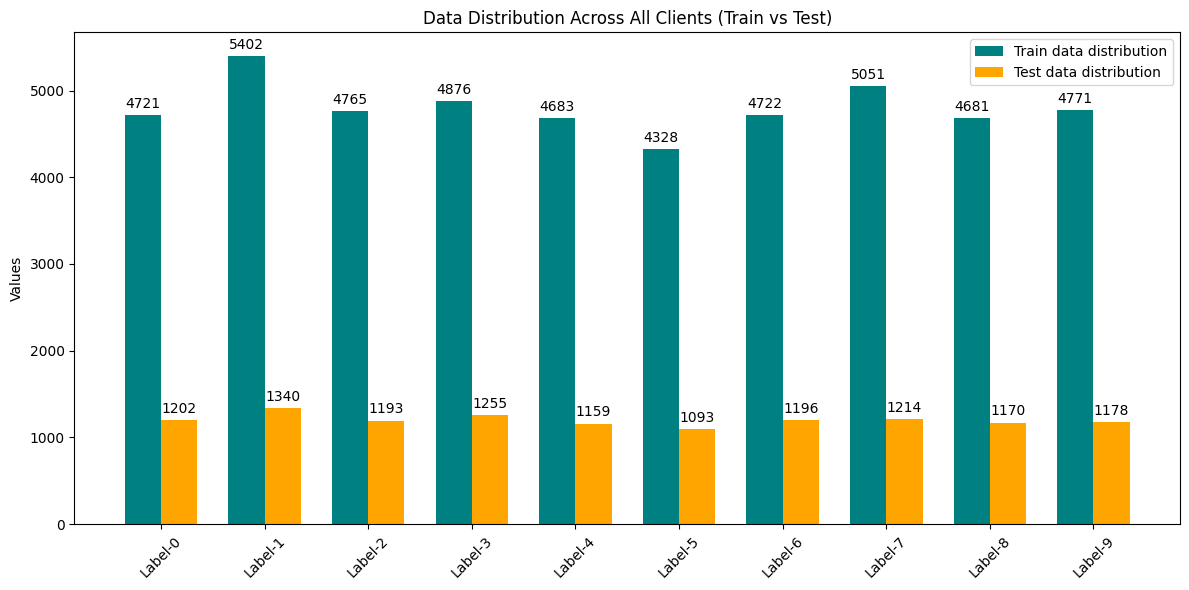

📦 - VANILLA-FL Policy - Round 0/20


📦 - VANILLA-FL Policy - Round 1/20
Device client_0 checks: {'battery_ok': True, 'memory_ok': True, 'network_ok': True, 'health_ok': True, 'performance_ok': np.True_}
Device client_1 checks: {'battery_ok': True, 'memory_ok': True, 'network_ok': True, 'health_ok': True, 'performance_ok': np.True_}
Device client_2 checks: {'battery_ok': True, 'memory_ok': True, 'network_ok': True, 'health_ok': True, 'performance_ok': np.True_}
Device client_3 checks: {'battery_ok': True, 'memory_ok': True, 'network_ok': True, 'health_ok': True, 'performance_ok': np.True_}
Device client_4 checks: {'battery_ok': True, 'memory_ok': True, 'network_ok': True, 'health_ok': True, 'performance_ok': np.True_}
Device client_5 checks: {'battery_ok': True, 'memory_ok': True, 'network_ok': True, 'health_ok': True, 'performance_ok': np.True_}
Device client_6 checks: {'battery_ok': True, 'memory_ok': True, 'network_ok': True, 'health_ok': True, 'performance_ok': np.True_}
Device client_7 checks: {'battery_ok': True, 'me

TypeError: normal() received an invalid combination of arguments - got (int, float), but expected one of:
 * (Tensor mean, Tensor std, *, torch.Generator generator = None, Tensor out = None)
 * (Tensor mean, float std = 1, *, torch.Generator generator = None, Tensor out = None)
 * (float mean, Tensor std, *, torch.Generator generator = None, Tensor out = None)
 * (float mean, float std, tuple of ints size, *, torch.Generator generator = None, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)


In [29]:
sim = Simulation(
    num_devices=100,
    num_rounds=20,
    num_devices_per_round=10,
    alpha=0.5,
    distribution="iid",  # 'iid' or 'non_iid'
    dp_enabled=True,  # 'True' or 'False'
    model_type="cnn",  # 'cnn' or 'mobilenet' or 'resnet18'
    optimizer_type="adam",  # 'adam' or 'sdg'
    dataset_name="MNIST",  # 'MNIST' or 'FashionMNIST' or 'NSL-KDD'
    broadcast_mode="all_active",
)
for policy in ["vanilla-fl", "greedy", "moo-ema", "moo-ml", "fedcs", "poc"]:
    sim.run(policy=policy)


In [ ]:
def plot_metrics(metrics, K, num_devices):
    # rounds = list(range(20 + 1))
    fig, axs = plt.subplots(5, 2, figsize=(18, 30))  # Expand for new plots
    policies = list(metrics.keys())
    colors_styles = {
        "vanilla-fl": ("c", "d-"),
        "moo-ema": ("b", "^-"),
        "moo-ml": ("m", "P-"),
        "greedy": ("g", "s-"),
        "fedcs":("r", "1-"),
        "poc":("y", "o-"),
    }

    # Avg Battery: Shows mean % across alive devices; drops as depletion rises
    for policy in policies:
        color, style = colors_styles.get(policy, ("k", "-"))
        label = policy
        axs[0, 0].plot(
            list(range(len(metrics[policy]["avg_battery"]))),
            metrics[policy]["avg_battery"],
            style,
            color=color,
            label=label,
        )
    axs[0, 0].set_title(
        "Average Battery Level (%) - Mean Across Alive Devices Over Rounds"
    )
    axs[0, 0].set_xlabel("Rounds")
    axs[0, 0].set_ylabel("Battery Level (%)")
    axs[0, 0].legend()
    axs[0, 0].grid(True)
    axs[0, 0].set_ylim(0, 100)
    plt.savefig("network_survival_rate.png")

    # Survival Rate: % devices with battery >0; measures network longevity
    for policy in policies:
        color, style = colors_styles.get(policy, ("k", "-"))
        label = policy
        axs[0, 1].plot(
            list(range(len(metrics[policy]["survival_rate"]))),
            metrics[policy]["survival_rate"],
            style,
            color=color,
            label=label,
        )
    axs[0, 1].set_title(
        "Network Survival Rate (%) - Proportion of Alive Devices Over Rounds"
    )
    axs[0, 1].set_xlabel("Rounds")
    axs[0, 1].set_ylabel("Survival Rate (%)")
    axs[0, 1].axhline(
        y=(K / num_devices) * 100,
        color="r",
        linestyle="--",
        label="K Threshold",
    )
    axs[0, 1].legend()
    axs[0, 1].grid(True)
    axs[0, 1].set_ylim(0, 100)
    plt.savefig("network_survival_rate.png")

    # Packet Success: Fraction of successful updates; reflects network reliability
    for policy in policies:
        color, style = colors_styles.get(policy, ("k", "-"))
        label = policy
        axs[1, 0].plot(
            list(range(len(metrics[policy]["packet_success_rate"]))),
            metrics[policy]["packet_success_rate"],
            style,
            color=color,
            label=label,
        )
    axs[1, 0].set_title("Packet Success Rate - Successful Updates Per Round")
    axs[1, 0].set_xlabel("Rounds")
    axs[1, 0].set_ylabel("Success Rate")
    axs[1, 0].legend()
    axs[1, 0].grid(True)
    axs[1, 0].set_ylim(0, 1)
    plt.savefig("average_latency.png")

    # Avg Latency: Mean ms for broadcasts; indicates comm delays
    for policy in policies:
        color, style = colors_styles.get(policy, ("k", "-"))
        label = policy
        axs[1, 1].plot(
            list(range(len(metrics[policy]["avg_latency"]))),
            metrics[policy]["avg_latency"],
            style,
            color=color,
            label=label,
        )
    axs[1, 1].set_title("Average Latency (ms) - Mean Broadcast Delay Per Round")
    axs[1, 1].set_xlabel("Rounds")
    axs[1, 1].set_ylabel("Latency (ms)")
    axs[1, 1].legend()
    axs[1, 1].grid(True)
    plt.savefig("average_latency.png")

    # Cumulative Energy: Total mAh depleted system-wide; rises over time
    for policy in policies:
        color, style = colors_styles.get(policy, ("k", "-"))
        label = policy
        axs[2, 0].plot(
            list(range(len(metrics[policy]["cum_energy"]))),
            metrics[policy]["cum_energy"],
            style,
            color=color,
            label=label,
        )
    axs[2, 0].set_title(
        "Cumulative Energy Consumption (mAh) - System-Wide Depletion Over Rounds"
    )
    axs[2, 0].set_xlabel("Rounds")
    axs[2, 0].set_ylabel("Total Depletion (mAh)")
    axs[2, 0].legend()
    axs[2, 0].grid(True)
    plt.savefig("energy_efficiency_ratio.png")

    # Energy Efficiency: Acc per mAh; measures performance per energy cost
    for policy in policies:
        color, style = colors_styles.get(policy, ("k", "-"))
        label = policy
        axs[2, 1].plot(
            list(range(len(metrics[policy]["energy_efficiency"]))),
            metrics[policy]["energy_efficiency"],
            style,
            color=color,
            label=label,
        )
    axs[2, 1].set_title(
        "Energy Efficiency Ratio (Acc / mAh) - Global Accuracy Per Total Depletion Over Rounds"
    )
    axs[2, 1].set_xlabel("Rounds")
    axs[2, 1].set_ylabel("Accuracy per mAh")
    axs[2, 1].legend()
    axs[2, 1].grid(True)
    plt.savefig("network_lifetime_decrease_rate.png")

    # Lifetime Decrease Rate: % depletion drop per round; shows acceleration of drain
    for policy in policies:
        color, style = colors_styles.get(policy, ("k", "-"))
        label = policy
        axs[3, 0].plot(
            list(range(len(metrics[policy]["lifetime_decrease_rate"]))),
            metrics[policy]["lifetime_decrease_rate"],
            style,
            color=color,
            label=label,
        )
    axs[3, 0].set_title(
        "Network Lifetime Decrease Rate (%) - Per-Round % Drop in Cumulative Energy Over Rounds"
    )
    axs[3, 0].set_xlabel("Rounds")
    axs[3, 0].set_ylabel("Decrease Rate (%)")
    axs[3, 0].legend()
    axs[3, 0].grid(True)
    plt.savefig("normalized_objective_functions.png")

    # Objectives: Normalized values over rounds; shows MOO balance
    if "moo" in metrics:
        moo_rounds = list(range(len(metrics["moo"]["objectives"]["depletion"])))
        axs[3, 1].plot(
            moo_rounds,
            metrics["moo"]["objectives"]["depletion"],
            label="Depletion (Norm)",
        )
        axs[3, 1].plot(
            moo_rounds,
            metrics["moo"]["objectives"]["convergence"],
            label="Convergence (Norm)",
        )
        axs[3, 1].plot(
            moo_rounds,
            metrics["moo"]["objectives"]["fairness"],
            label="Fairness (Norm)",
        )
        axs[3, 1].plot(
            moo_rounds,
            metrics["moo"]["objectives"]["energy_eff"],
            label="Energy Eff (Norm)",
        )
        axs[3, 1].set_title("Normalized Objective Functions Over Rounds for MOO")
        axs[3, 1].set_xlabel("Rounds")
        axs[3, 1].set_ylabel("Normalized Value [0-1]")
        axs[3, 1].legend()
        axs[3, 1].grid(True)
        axs[3, 1].set_ylim(0, 1)
        plt.savefig("normalized_objective_functions.png")

    # Alive Devices: Absolute number over rounds; shows decay
    for policy in policies:
        color, style = colors_styles.get(policy, ("k", "-"))
        label = policy
        axs[4, 0].plot(
            list(range(len(metrics[policy]["total_battery"]))),
            metrics[policy]["total_battery"],
            style,
            color=color,
            label=label,
        )
    axs[4, 0].set_title("Residual Energy Over Rounds")
    axs[4, 0].set_xlabel("Rounds")
    axs[4, 0].set_ylabel("Residual energy")
    axs[4, 0].legend()
    axs[4, 0].grid(True)
    axs[4, 0].set_ylim(0, num_devices)
    plt.savefig("battery_distribution.png")

    # Battery Distrib: Boxplot of levels at key rounds; shows variance/heterogeneity
    fig_bd, ax_bd = plt.subplots(1, 4, figsize=(18, 4))

    for idx, policy in enumerate(policies):
        policy_len = len(metrics[policy]["battery_distribs"])
        select_rounds = [
            0,
            policy_len // 4,
            policy_len // 2,
            3 * policy_len // 4,
            policy_len - 1,
        ]
        distribs = [metrics[policy]["battery_distribs"][r] for r in select_rounds]
        ax_bd[idx].boxplot(distribs, labels=[f"R{r+1}" for r in select_rounds])
        ax_bd[idx].set_title(f"Battery Distribution (%) - {policy.upper()}")
        ax_bd[idx].set_xlabel("Selected Rounds")
        ax_bd[idx].set_ylabel("Battery Level (%)")
        ax_bd[idx].grid(True)
        ax_bd[idx].set_ylim(0, 100)
    fig_bd.savefig("battery_distribution.png")

    # Separate fig for full ML metrics: Acc, Loss, Prec, Recall, F1 over rounds
    fig_ml, ax_ml = plt.subplots(1, 4, figsize=(18, 5))
    for idx, policy in enumerate(policies):
        policy_rounds = list(range(len(metrics[policy]["global_acc"])))
        ax_ml[idx].plot(
            policy_rounds, metrics[policy]["global_acc"], "o-", label="Accuracy"
        )
        ax_ml[idx].plot(
            policy_rounds, metrics[policy]["global_loss"], "v-", label="Loss"
        )
        ax_ml[idx].plot(
            policy_rounds,
            metrics[policy]["precision"],
            "x-",
            label="Precision (Macro Avg)",
        )
        ax_ml[idx].plot(
            policy_rounds, metrics[policy]["recall"], "s-", label="Recall (Macro Avg)"
        )
        ax_ml[idx].plot(
            policy_rounds,
            metrics[policy]["f1_score"],
            "*-",
            label="F1-Score (Macro Avg)",
        )
        ax_ml[idx].set_title(f"Global Model ML Metrics Over Rounds - {policy}")
        ax_ml[idx].set_xlabel("Rounds")
        ax_ml[idx].set_ylabel("Metric Value")
        ax_ml[idx].legend()
        ax_ml[idx].grid(True)
    fig_ml.savefig("ml_metrics.png")

    plt.tight_layout()
    plt.show()
    fig_bd.tight_layout()
    plt.show()
    fig_ml.tight_layout()
    plt.show()

    comparison_data = {
        "Policy": policies,
        "Final Acc (%)": [metrics[p]["global_acc"][-1] for p in policies],
        "Survival Rate (%)": [metrics[p]["survival_rate"][-1] for p in policies],
        "Energy Eff (Acc/mAh)": [metrics[p]["energy_efficiency"][-1] for p in policies],
    }
    df_comp = pd.DataFrame(comparison_data)
    print(df_comp.to_markdown(index=False))


def plot_client_metrics(simulator, save_path="client_ml_metrics.png"):
    client_accs = [
        d.local_metrics["acc"] for d in simulator.devices if d.local_metrics["acc"]
    ]

    if not client_accs:
        print("No client accuracy metrics available to plot.")
        return

    # Find max rounds across clients
    max_rounds = max(len(acc) for acc in client_accs)
    num_clients = len(client_accs)

    # Pad accuracies to [num_clients, max_rounds] with 0 for missing (or np.nan if prefer)
    acc_matrix = np.zeros((num_clients, max_rounds))
    for i, acc in enumerate(client_accs):
        acc_matrix[i, : len(acc)] = acc

    # Create meshgrid for x (clients), y (rounds)
    x = np.arange(num_clients)  # Clients 0 to N-1
    y = np.arange(max_rounds)  # Rounds 0 to M-1
    x, y = np.meshgrid(x, y)  # Grid for bars
    z = acc_matrix.T.flatten()  # Heights (transpose to match dims)
    dx = dy = 0.8  # Bar width/depth
    dz = z  # Height = accuracy

    # Normalize for colormap (purple low to yellow high)
    norm = plt.Normalize(vmin=0, vmax=100)  # Acc 0-100
    colors = plt.cm.viridis(norm(dz))  # Or jet for purple-blue-green-yellow

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.bar3d(x.flatten(), y.flatten(), np.zeros_like(z), dx, dy, dz, color=colors)

    # Labels and title like image
    ax.set_xlabel("Number of Clients")
    ax.set_ylabel("Communications Rounds(CR)")
    ax.set_zlabel("Accuracy")
    ax.set_title("Clients vs CR vs Accuracy")

    # Set limits/view
    ax.set_xlim(0, num_clients)
    ax.set_ylim(0, max_rounds)
    ax.set_zlim(0, 100)
    ax.view_init(elev=20, azim=-135)  # Adjust to match image angle

    plt.tight_layout()
    plt.show()
    plt.savefig(save_path)
    plt.close()


In [ ]:
metrics_path = "metrics.json"
with open(metrics_path, "r") as f:
    metrics = json.load(f)
plot_metrics(metrics, sim.K, sim.num_devices)

client_metrics_path = "client_metrics.json"
with open(metrics_path, "r") as f:
    client_metrics = json.load(f)
plot_client_metrics(simulator=sim)
